## Load dataset

In [59]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def load_images_and_labels(root_folder, size=(32, 32)):
    images = []
    labels = []
    filenames = []

    for person_name in os.listdir(root_folder):
        person_folder = os.path.join(root_folder, person_name)
        if os.path.isdir(person_folder):
            for filename in os.listdir(person_folder):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.heic')):
                    img_path = os.path.join(person_folder, filename)
                    img = Image.open(img_path).convert('L')
                    img = img.resize(size)
                    img_array = np.array(img).flatten()
                    images.append(img_array)
                    labels.append(person_name)
                    filenames.append(filename)

    return np.array(images), np.array(labels), filenames

root_folder = './faces_dataset'
X, y_labels, filenames = load_images_and_labels(root_folder)

print(f"Total samples: {len(X)}")
print(f"Image shape (flattened): {X.shape}")
print(f"Example labels: {np.unique(y_labels)}")

Total samples: 110
Image shape (flattened): (110, 1024)
Example labels: ['big' 'debit' 'kwankao' 'meen' 'noey' 'peace' 'peem' 'piano' 'pun'
 'tangkwa' 'tie']


## Split into Train/Test/Validation Set

In [60]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(X, y_labels))
X_train_valid = X[train_valid_idx]
y_train_valid = y_labels[train_valid_idx]
X_test = X[test_idx]
y_test = y_labels[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=43)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X_train_valid[train_idx]
y_train = y_train_valid[train_idx]
X_valid = X_train_valid[valid_idx]
y_valid = y_train_valid[valid_idx]

In [61]:
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Valid: {X_valid.shape}, {y_valid.shape}")
print(f"Test : {X_test.shape}, {y_test.shape}")

Train: (70, 1024), (70,)
Valid: (18, 1024), (18,)
Test : (22, 1024), (22,)


## PCA

In [62]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(53)

## K-Means

In [63]:
from sklearn.cluster import KMeans

k_range = range(5, 75, 5)
kmeans_per_k = []
for k in k_range:
    print(f"k={k}")
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_per_k.append(kmeans)

k=5
k=10
k=15
k=20
k=25
k=30
k=35
k=40
k=45
k=50
k=55
k=60
k=65
k=70


k=70


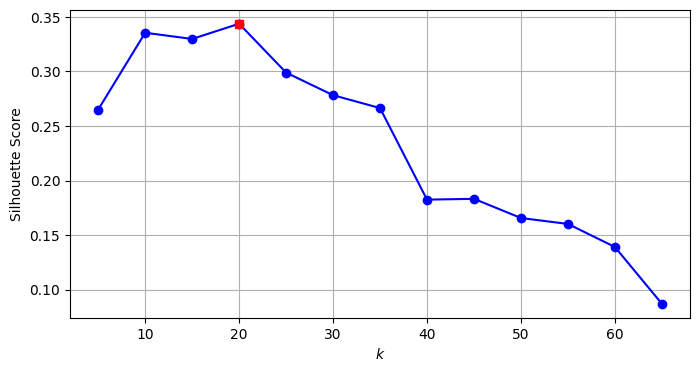

In [64]:
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

silhouette_scores = []
valid_ks = []

for k, model in zip(k_range, kmeans_per_k):
    n_labels = len(set(model.labels_))
    n_samples = len(X_train_pca)

    if n_labels >= 2 and n_labels < n_samples:
        score = silhouette_score(X_train_pca, model.labels_)
        silhouette_scores.append(score)
        valid_ks.append(k)
    else:
        print(f"k={k}")

best_index = np.argmax(silhouette_scores)
best_k = valid_ks[best_index]
best_score = silhouette_scores[best_index]

plt.figure(figsize=(8, 4))
plt.plot(valid_ks, silhouette_scores, "bo-")
plt.plot(best_k, best_score, "rs")
plt.xlabel("$k$")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

In [65]:
best_k

20

## Inertia

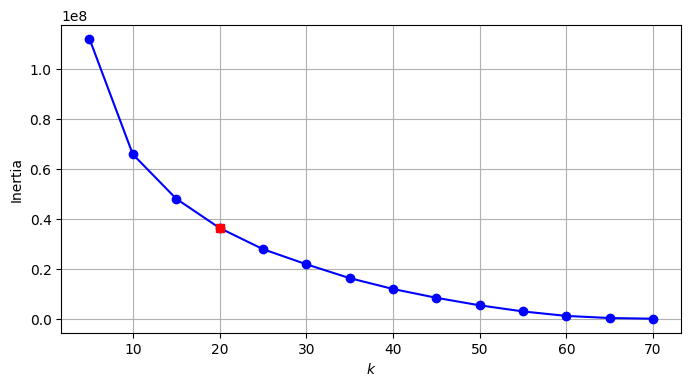

In [66]:
inertias = [model.inertia_ for model in kmeans_per_k]
best_inertia = inertias[best_index]

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.plot(best_k, best_inertia, "rs")
plt.grid()
plt.show()



## Display Each Cluster

Cluster 0


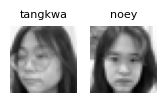

Cluster 1


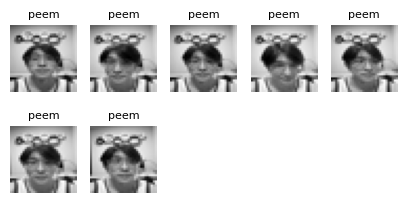

Cluster 2


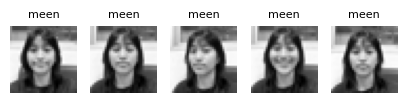

Cluster 3


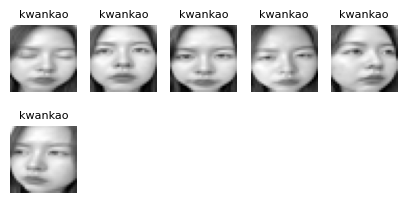

Cluster 4


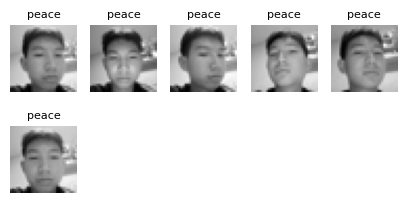

Cluster 5


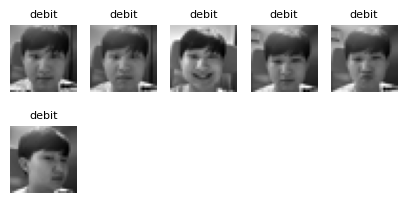

Cluster 6


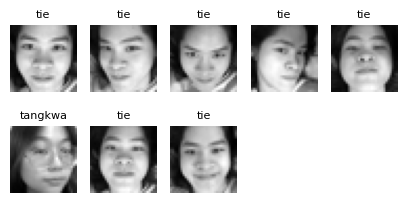

Cluster 7


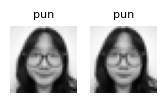

Cluster 8


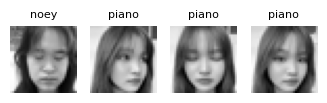

Cluster 9


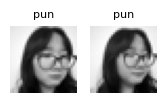

Cluster 10


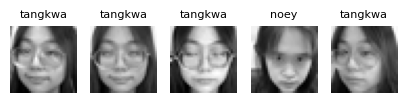

Cluster 11


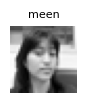

Cluster 12


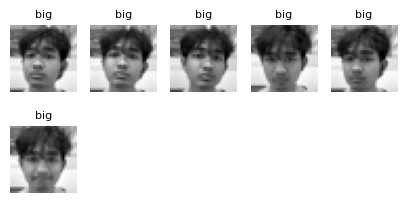

Cluster 13


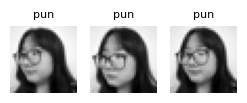

Cluster 14


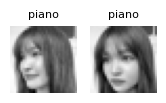

Cluster 15


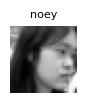

Cluster 16


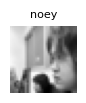

Cluster 17


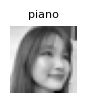

Cluster 18


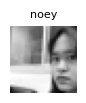

Cluster 19


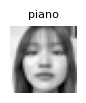

In [67]:
best_model = kmeans_per_k[best_index]

def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 32, 32)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.2))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label, fontsize=8)
    plt.show()

for cluster_id in np.unique(best_model.labels_):
    print(f"Cluster {cluster_id}")
    in_cluster = best_model.labels_ == cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

## Classification

Encoding

In [68]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)
y_test_encoded = label_encoder.transform(y_test)

n_classes = len(label_encoder.classes_)
print("Number of classes (people):", n_classes)
print("Mapping (label -> number):")
for name, number in zip(label_encoder.classes_, range(n_classes)):
    print(f"{name}: {number}")

Number of classes (people): 11
Mapping (label -> number):
big: 0
debit: 1
kwankao: 2
meen: 3
noey: 4
peace: 5
peem: 6
piano: 7
pun: 8
tangkwa: 9
tie: 10


Feature Scaling and Tensor

In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

print(X_train_tensor.shape, y_train_tensor.shape)


torch.Size([70, 1024]) torch.Size([70])


ANN

In [70]:
class FaceClassifierANN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FaceClassifierANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train_tensor.shape[1]
num_classes = n_classes

model = FaceClassifierANN(input_dim, num_classes)
print(model)

FaceClassifierANN(
  (model): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=11, bias=True)
  )
)


In [71]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [72]:
num_epochs = 100
for epoch in range(num_epochs):
    y_pred = model(X_train_tensor)
    loss = loss_function(y_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")


Epoch 10/100, Loss: 0.5664
Epoch 20/100, Loss: 0.0461
Epoch 30/100, Loss: 0.0039
Epoch 40/100, Loss: 0.0011
Epoch 50/100, Loss: 0.0006
Epoch 60/100, Loss: 0.0004
Epoch 70/100, Loss: 0.0003
Epoch 80/100, Loss: 0.0003
Epoch 90/100, Loss: 0.0002
Epoch 100/100, Loss: 0.0002


In [73]:
with torch.no_grad():
    y_val_pred = model(X_valid_tensor)
    val_pred_labels = torch.argmax(y_val_pred, dim=1)
    accuracy = (val_pred_labels == y_valid_tensor).float().mean().item()
    print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.8889


In [74]:
with torch.no_grad():
    y_test_pred = model(X_test_tensor)
    test_pred_labels = torch.argmax(y_test_pred, dim=1)
    test_accuracy = (test_pred_labels == y_test_tensor).float().mean().item()
    print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8636
